# Notebook 06 — Word2Vec Feature Extraction

Build dense 100-dimensional semantic embeddings from tokenised support tickets using Word2Vec (CBOW). Outputs are train/test split `.npy` matrices aligned to the same row indices produced in notebook 05.

In [1]:
import ast
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

## Step 1 — Load Data and Restore Token Lists

Tokens were saved to CSV as a plain string (`"['refund', 'payment']"`), not a Python list. `ast.literal_eval` reads the string and returns the actual list — safe here because the strings are well-formed Python list literals written by our own preprocessing code.

In [2]:
df = pd.read_csv('../data/processed/preprocessed_tasks.csv')

df['lemmatized_tokens'] = df['tokens_str'].apply(ast.literal_eval)

# --- verification ---
print(type(df['lemmatized_tokens'].iloc[0]))           # must be <class 'list'>
print(df['lemmatized_tokens'].iloc[0])                 # content without outer quotes
min_len = df['lemmatized_tokens'].apply(len).min()
print(f'Minimum token list length: {min_len}')         # must be > 0
assert min_len > 0, 'Empty token lists found — check preprocessing output'
print(f'Rows loaded: {len(df)}')

<class 'list'>
['product', 'setup', 'website', 'address', 'ive', 'try', 'troubleshoot', 'step']
Minimum token list length: 5
Rows loaded: 8077


## Step 2 — Build Sentence Corpus

Word2Vec expects a **list of lists**: the outer list holds all documents; each inner list holds the tokens of one document. Although Word2Vec was designed for sentences, each support ticket is treated as one training unit (the same "sentence corpus" convention used throughout NLP).

In [3]:
corpus = df['lemmatized_tokens'].tolist()

print(f'Corpus size  : {len(corpus)} documents')
print(f'Sample doc   : {corpus[0]}')

Corpus size  : 8077 documents
Sample doc   : ['product', 'setup', 'website', 'address', 'ive', 'try', 'troubleshoot', 'step']


## Step 3 — Train Word2Vec

Parameter rationale for **8,077 tickets / ~154,000 total tokens / 5,577 unique tokens**:

| Parameter | Value | Rationale |
|---|---|---|
| `vector_size` | 100 | ~27 occurrences per unique word; 300-d would under-train, 100 balances expressiveness with data size |
| `window` | 5 | Covers ~half of a 19-word ticket; window=2 is too narrow, window=10 loses positional signal |
| `min_count` | 2 | Excludes true hapax legomena while keeping vocabulary as wide as possible on a small corpus |
| `sg` | 0 | CBOW — better on small corpora with frequent words; Skip-gram favours rare technical jargon |
| `epochs` | 15 | Extra passes compensate for small corpus — each word-context pair seen ~15× |
| `workers` | 3 | CPU cores minus one (4 cores available — one reserved for the OS) |
| `seed` | 42 | Reproducible training |

In [4]:
model = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=2,
    sg=0,
    epochs=15,
    workers=3,
    seed=42
)

print(f'Vocabulary size : {len(model.wv)}')
print(f'Vector dims     : {model.wv.vector_size}')

Vocabulary size : 2360
Vector dims     : 100


## Step 4 — Verify Embeddings

Similarity tests confirm the model learned domain-relevant semantic clusters. If `most_similar('refund')` returns words from a completely different ticket category (e.g. `device`, `network`) the corpus was too small for Word2Vec to converge — document this and proceed.

In [5]:
# --- similarity tests ---
probes = {
    'refund'  : ['return', 'money', 'payment', 'charge', 'cancel'],
    'software': ['update', 'install', 'device', 'hardware', 'error'],
    'account' : ['login', 'access', 'password', 'credential'],
}
for probe, expected in probes.items():
    if probe in model.wv:
        results = [w for w, _ in model.wv.most_similar(probe, topn=5)]
        hits = [w for w in results if w in expected]
        print(f"most_similar('{probe}'): {results}  — expected overlap: {hits}")
    else:
        print(f"'{probe}' not in vocabulary")

# --- vocabulary coverage ---
key_terms = ['software', 'account', 'device', 'network', 'error',
             'bug', 'hardware', 'billing', 'refund', 'cancel']
print('\nVocabulary coverage:')
for term in key_terms:
    status = 'PRESENT' if term in model.wv else 'MISSING'
    print(f'  {term:<15} {status}')

most_similar('refund'): ['payment', 'installation', 'delivery', 'cancellation', 'seller']  — expected overlap: ['payment']
most_similar('software'): ['useful', 'change', 'fix', 'make', 'internationally']  — expected overlap: []
most_similar('account'): ['password', 'username', 'login', 'regain', 'log']  — expected overlap: ['password', 'login']

Vocabulary coverage:
  software        PRESENT
  account         PRESENT
  device          PRESENT
  network         PRESENT
  error           PRESENT
  bug             PRESENT
  hardware        PRESENT
  billing         PRESENT
  refund          PRESENT
  cancel          PRESENT


## Step 5 — Generate Document Vectors (Mean Pooling)

Word2Vec produces one 100-d vector per **word**. Mean pooling aggregates these into one 100-d vector per **ticket** by averaging all in-vocabulary token vectors. Tokens absent from the Word2Vec vocabulary (filtered by `min_count`) are skipped. If every token in a ticket is out-of-vocabulary the row receives a zero vector — these are flagged below.

In [6]:
def mean_pool(tokens, wv, dims=100):
    vecs = [wv[t] for t in tokens if t in wv]
    if not vecs:
        return np.zeros(dims)
    return np.mean(vecs, axis=0)

X_w2v = np.vstack([
    mean_pool(tokens, model.wv) for tokens in df['lemmatized_tokens']
])

zero_rows = (X_w2v == 0).all(axis=1).sum()
print(f'Document matrix shape : {X_w2v.shape}')    # expect (8077, 100)
print(f'Zero-vector rows      : {zero_rows}')       # should be 0 or very few

Document matrix shape : (8077, 100)
Zero-vector rows      : 0


## Step 6 — Split Using Existing Indices

Re-splitting randomly would produce a different train/test partition than notebook 05, making cross-feature comparison impossible. Load the label files saved by notebook 05 and use their DataFrame indices to slice the embedding matrix — this guarantees row-for-row alignment between `X_train_w2v` and `X_train_tfidf`.

In [7]:
y_train_type = pd.read_csv('../data/processed/y_train_type.csv', index_col=0)
y_test_type  = pd.read_csv('../data/processed/y_test_type.csv',  index_col=0)

train_idx = y_train_type.index.tolist()
test_idx  = y_test_type.index.tolist()

X_train_w2v = X_w2v[train_idx]
X_test_w2v  = X_w2v[test_idx]

print(f'X_train_w2v : {X_train_w2v.shape}')   # expect (6461, 100)
print(f'X_test_w2v  : {X_test_w2v.shape}')    # expect (1616, 100)

X_train_w2v : (6461, 100)
X_test_w2v  : (1616, 100)


## Step 7 — PCA Visualisation

Reduce the 8,077 × 100 embedding matrix to 2 dimensions with PCA. A scatter plot coloured by `task_type` shows whether Word2Vec has separated task categories in semantic space. Tight, well-separated clusters indicate the embeddings carry class signal; a single overlapping blob means the small corpus limited convergence.

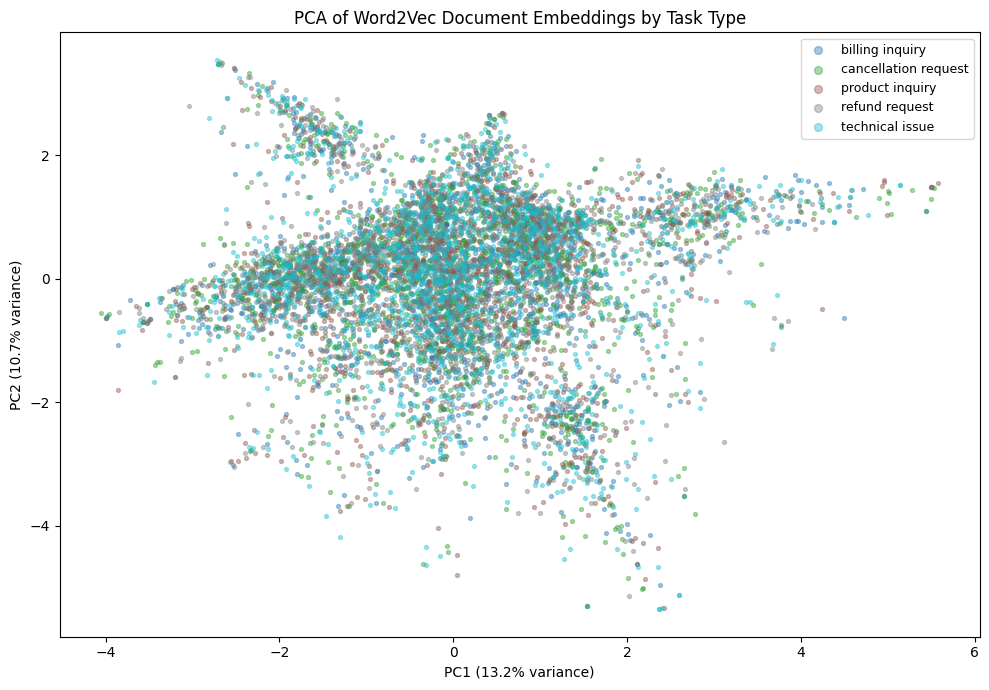

Explained variance — PC1: 0.132, PC2: 0.107


In [8]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_w2v)

labels = df['task_type'].values
unique_labels = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

fig, ax = plt.subplots(figsize=(10, 7))
for label, color in zip(unique_labels, colors):
    mask = labels == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color], label=label, alpha=0.4, s=8)

ax.set_title('PCA of Word2Vec Document Embeddings by Task Type')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/word2vec_pca.png', dpi=150)
plt.show()
print(f'Explained variance — PC1: {pca.explained_variance_ratio_[0]:.3f}, '
      f'PC2: {pca.explained_variance_ratio_[1]:.3f}')

## Step 8 — Save Artefacts

| File | Format | Purpose |
|---|---|---|
| `models/word2vec.model` | gensim native | Full model — vocabulary, vectors, training state; needed for Streamlit inference |
| `data/processed/X_w2v.npy` | NumPy binary | Full 8,077 × 100 matrix — for future experiments needing all rows |
| `data/processed/X_train_w2v.npy` | NumPy binary | Train split — loaded by notebook 08 for classification |
| `data/processed/X_test_w2v.npy` | NumPy binary | Test split — loaded by notebook 09 for evaluation |

In [9]:
model.save('../models/word2vec.model')
np.save('../data/processed/X_w2v.npy',       X_w2v)
np.save('../data/processed/X_train_w2v.npy', X_train_w2v)
np.save('../data/processed/X_test_w2v.npy',  X_test_w2v)

print('Saved:')
for p in [
    '../models/word2vec.model',
    '../data/processed/X_w2v.npy',
    '../data/processed/X_train_w2v.npy',
    '../data/processed/X_test_w2v.npy',
]:
    size_kb = pathlib.Path(p).stat().st_size / 1024 if pathlib.Path(p).exists() else 0
    print(f'  {p}  ({size_kb:.1f} KB)')

Saved:
  ../models/word2vec.model  (1928.1 KB)
  ../data/processed/X_w2v.npy  (3155.2 KB)
  ../data/processed/X_train_w2v.npy  (2524.0 KB)
  ../data/processed/X_test_w2v.npy  (631.4 KB)
